# Example: King County Housing

Can we do better fitting the King County Housing dataset with polynomial features?

In [24]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV
from sklearn.metrics import root_mean_squared_error, r2_score

## Data cleaning

In [25]:

housing_df = pd.read_csv('https://raw.githubusercontent.com/GettysburgDataScience/datasets/refs/heads/main/kc_house_data.csv')


# Change year built and year renovated to age of home and age of latest renovation
housing_df.loc[housing_df['yr_renovated']==0, 'yr_renovated'] = housing_df.loc[housing_df['yr_renovated']==0, 'yr_built']
housing_df['yr_sold'] = housing_df['date'].apply(lambda d: int(d[0:4]))
housing_df['age_built'] = housing_df['yr_sold'] - housing_df['yr_built']
housing_df['age_reno'] = housing_df['yr_sold'] - housing_df['yr_renovated']


In [26]:
# limit search to single-family homes (not apartments or apartment buildings)
housing_df = housing_df.query('3<=bedrooms<=5')

In [27]:
columns_to_drop = ['id','date', 'yr_built', 'yr_renovated', 'yr_sold', 'lat', 'long', 'waterfront', 'view', 'zipcode']
housing_df.drop(columns = columns_to_drop, inplace=True)

# Remove rows with missing data
housing_df.dropna(inplace=True)

In [28]:
housing_df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15,age_built,age_reno
count,18307.00,18307.00,18307.00,18307.00,18307.00,18307.00,18307.00,18307.00,18307.00,18307.00,18307.00,18307.00,18307.00,18307.00
mean,557850.40,3.55,2.22,2195.92,15487.55,1.52,3.42,7.78,1887.19,308.73,2059.85,13178.90,40.50,38.17
std,368970.13,0.65,0.71,870.62,40349.57,0.53,0.65,1.14,811.95,449.36,684.04,27242.83,27.94,27.19
min,82000.00,3.00,0.50,490.00,520.00,1.00,1.00,4.00,490.00,0.00,399.00,651.00,-1.00,-1.00
25%,330000.00,3.00,1.75,1570.00,5427.50,1.00,3.00,7.00,1290.00,0.00,1550.00,5440.00,17.00,15.00
50%,467500.00,3.00,2.25,2030.00,7910.00,1.50,3.00,8.00,1670.00,0.00,1920.00,7875.00,37.00,35.00
75%,666000.00,4.00,2.50,2640.00,11052.00,2.00,4.00,8.00,2320.00,600.00,2440.00,10350.00,58.00,55.00
max,7062500.00,5.00,6.75,10040.00,1651359.00,3.50,5.00,13.00,8020.00,4820.00,6210.00,871200.00,115.00,115.00


## Pre-processing


In [29]:
target = 'price'

y = housing_df[target]
X = housing_df.drop(columns = target)

In [30]:
X.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'condition', 'grade', 'sqft_above', 'sqft_basement', 'sqft_living15',
       'sqft_lot15', 'age_built', 'age_reno'],
      dtype='object')

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [32]:
poly = PolynomialFeatures(degree = 2, include_bias = False)
Xp_train = poly.fit_transform(X_train)
Xp_test = poly.transform(X_test)

sc = StandardScaler()
Z_train = sc.fit_transform(Xp_train)
Z_test = sc.transform(Xp_test)

In [33]:
# PolynomialFeatures returns a numpy array. 
# Let's convert to a Pandas DataFrame for nicer viewing.
feature_names = poly.get_feature_names_out()

Xtrain_df = pd.DataFrame(data = Z_train, columns = feature_names)
Xtrain_df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,sqft_living15,...,sqft_living15^2,sqft_living15 sqft_lot15,sqft_living15 age_built,sqft_living15 age_reno,sqft_lot15^2,sqft_lot15 age_built,sqft_lot15 age_reno,age_built^2,age_built age_reno,age_reno^2
0,-0.85,-1.69,-0.74,-0.07,-0.98,0.90,-0.69,-0.42,-0.68,-0.74,...,-0.68,-0.23,0.09,0.18,-0.08,-0.01,0.01,0.13,0.21,0.22
1,0.69,-1.69,-1.08,-0.28,-0.98,0.90,-0.69,-0.78,-0.68,-1.05,...,-0.86,-0.35,1.11,1.25,-0.08,-0.06,-0.04,2.83,3.08,3.08
2,-0.85,0.40,0.85,0.45,0.90,-0.64,1.07,1.29,-0.68,2.44,...,2.71,1.40,-0.46,-0.40,0.03,0.01,0.04,-0.77,-0.75,-0.73
3,0.69,0.40,0.06,0.54,0.90,-0.64,0.19,0.44,-0.68,0.27,...,0.10,-0.01,-0.64,-0.58,-0.07,-0.24,-0.22,-0.72,-0.69,-0.67
4,-0.85,0.40,-0.45,-0.29,0.90,-0.64,0.19,-0.11,-0.68,-0.38,...,-0.43,-0.31,-0.56,-0.50,-0.08,-0.36,-0.36,-0.61,-0.57,-0.56


### Fitting the model

In [ ]:
test_alphas = np.logspace(-2,4, 19)
lasso = LassoCV(alphas=test_alphas, cv=5, max_iter = 30000)
lasso.fit(Z_train, y_train)


,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+04])
,fit_intercept,True
,precompute,'auto'
,max_iter,30000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


Let's inspect the fit coefficients.

In [ ]:
print(f'The best alpha = {lasso.alpha_:.5g}')

for k, (feature, weight) in enumerate(zip(feature_names, lasso.coef_)):
    print(f'{k:>3}.\t{feature:>20} \t {weight:+0.4f}')

The best alpha = 464.16
  0.	            bedrooms 	 -0.0000
  1.	           bathrooms 	 -0.0000
  2.	         sqft_living 	 -101376.0206
  3.	            sqft_lot 	 +46021.0372
  4.	              floors 	 +0.0000
  5.	           condition 	 -27133.7048
  6.	               grade 	 -5523.0165
  7.	          sqft_above 	 -0.0000
  8.	       sqft_basement 	 -0.0000
  9.	       sqft_living15 	 -94884.1463
 10.	          sqft_lot15 	 +17692.5381
 11.	           age_built 	 -46645.1272
 12.	            age_reno 	 -0.0000
 13.	          bedrooms^2 	 -0.0000
 14.	  bedrooms bathrooms 	 -0.0000
 15.	bedrooms sqft_living 	 -0.0000
 16.	   bedrooms sqft_lot 	 +0.0000
 17.	     bedrooms floors 	 +0.0000
 18.	  bedrooms condition 	 -0.0000
 19.	      bedrooms grade 	 -0.0000
 20.	 bedrooms sqft_above 	 +0.0000
 21.	bedrooms sqft_basement 	 -41073.5220
 22.	bedrooms sqft_living15 	 -5174.5315
 23.	 bedrooms sqft_lot15 	 +0.0000
 24.	  bedrooms age_built 	 +0.0000
 25.	   bedrooms age_reno 	 +0.0000
 

Same as above, but now the coefficients are in order of importance.

In [ ]:
# Same as above but sorted by importance

# np.argsort returns the order of indices in the reordered array
# I'm sorting the absolute value of the coefficients because it's the size of the coeff that's important

sort_order = np.argsort(np.abs(lasso.coef_))[::-1]

for k, (feature, weight) in enumerate(zip(feature_names[sort_order], lasso.coef_[sort_order]), start = 1):
    print(f'{k:>3}.\t{feature:>40} \t {weight:+0.4f}')

  1.	                 sqft_living15 age_built 	 +207428.9831
  2.	                                 grade^2 	 +115811.0922
  3.	                  sqft_living sqft_above 	 +111425.8364
  4.	                             sqft_living 	 -101376.0206
  5.	                           sqft_living15 	 -94884.1463
  6.	                       sqft_living grade 	 +83109.9795
  7.	                 condition sqft_living15 	 +70731.1051
  8.	                    floors sqft_living15 	 -67310.6046
  9.	                    bathrooms sqft_above 	 +64996.6286
 10.	                     grade sqft_basement 	 +57579.8073
 11.	                              age_reno^2 	 +56995.4397
 12.	                    sqft_living sqft_lot 	 -56149.1012
 13.	                sqft_above sqft_basement 	 +55471.8912
 14.	                               age_built 	 -46645.1272
 15.	                                sqft_lot 	 +46021.0372
 16.	                    sqft_living age_reno 	 -41533.4816
 17.	                  bedrooms sqft

In [ ]:

# Assessing model
y_lasso_test = lasso.predict(Z_test)
y_lasso_train = lasso.predict(Z_train)


rmse_lasso_train = root_mean_squared_error(y_train, y_lasso_train)
r2_lasso_train = r2_score(y_train, y_lasso_train)

rmse_lasso_test = root_mean_squared_error(y_test, y_lasso_test)
r2_lasso_test = r2_score(y_test, y_lasso_test)

print("Lasso Regression Performance (Standardized Target):\n")
print(f"  Train RMSE: {rmse_lasso_train:.3f}")
print(f"  Test  RMSE: {rmse_lasso_test:.3f}\n")

print(f"  Train R^2: {r2_lasso_train:.3f}")
print(f"  Test  R^2: {r2_lasso_test:.3f}")


Lasso Regression Performance (Standardized Target):

  Train RMSE: 199672.389
  Test  RMSE: 205729.638

  Train R^2: 0.709
  Test  R^2: 0.683


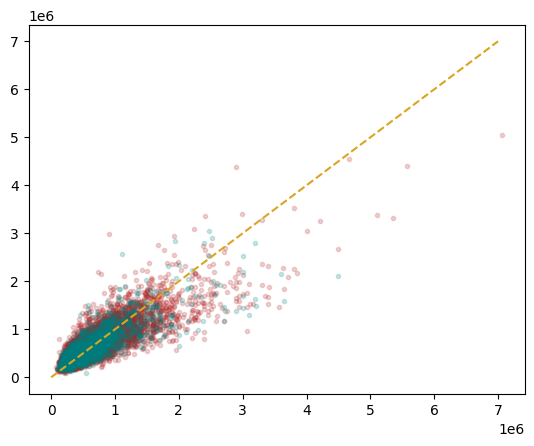

In [ ]:
plt.plot(y_train, y_lasso_train, '.', color = 'firebrick', label = 'train', alpha = 0.2)
plt.plot(y_test, y_lasso_test, '.', color = 'teal', label = 'test', alpha = 0.2)

plimits = [0, 7000000]
plt.plot(plimits, plimits, '--', color = 'goldenrod')

plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.show()

**Question**

Inspecting this result, where is the model over- or under-estimating house value? Can you think of a fix for this problem?